# LangGraph - Supervisor Agents

> Agents as a Tool

When designing a system where multiple specialized agents collaborate, a common architecthure is to use a supervisor agent that manages
communication and delegates tasks to the appropriate experts.

In this multi-agent pattern, a supervisor agent utilizes other agents as tools. These “tool” agents report their final task results to the supervisor, who then makes decisions based on this information.

![](assets/img/14-supervisor-agent-01.webp)

To kick things off, let’s start by defining our specialized agents. We’ll begin with the research agent.

In [1]:
from langchain_community.tools import TavilySearchResults

search = TavilySearchResults(search_kwargs={"count": 3})

/tmp/ipykernel_216648/1777058997.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  search = TavilySearchResults(search_kwargs={"count": 3})


To streamline the creation of specialized agents, LangGraph provides a convenient `create_react_agent` function. This allows to quicly instantiate agents with customization

In [2]:
from langgraph.prebuilt import create_react_agent

research_agent = create_react_agent(
    model="openai:gpt-4.1",
    tools=[search],
    prompt=(
        "You are a research agent.\n\n"
        "INSTRUCTIONS:\n"
        "- Assist ONLY with research-related tasks, DO NOT do any math\n"
        "- After you're done with your tasks, respond to the supervisor directly\n"
        "- Respond ONLY with the results of your work, do NOT include ANY other text."
    ),
    name="research_agent"
)

/tmp/ipykernel_216648/3287506996.py:3: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  research_agent = create_react_agent(


So, here are some helper functions to display the updates happening in the agents

In [3]:
from langchain_core.messages import convert_to_messages


def pretty_print_message(message, indent=False):
    pretty_message = message.pretty_repr(html=True)
    if not indent:
        print(pretty_message)
        return

    indented = "\n".join("\t" + c for c in pretty_message.split("\n"))
    print(indented)


def pretty_print_messages(update, last_message=False):
    is_subgraph = False
    if isinstance(update, tuple):
        ns, update = update
        # skip parent graph updates in the printouts
        if len(ns) == 0:
            return

        graph_id = ns[-1].split(":")[0]
        print(f"Update from subgraph {graph_id}:")
        print("\n")
        is_subgraph = True

    for node_name, node_update in update.items():
        update_label = f"Update from node {node_name}:"
        if is_subgraph:
            update_label = "\t" + update_label

        print(update_label)
        print("\n")

        if node_update:
            messages = convert_to_messages(node_update["messages"])
            if last_message:
                messages = messages[-1:]

            for m in messages:
                pretty_print_message(m, indent=is_subgraph)
        print("\n")

Now, when we want to stream and display the output of an agent (for example, the research agent answering “who is the mayor of NYC?”), we simply iterate over its `stream()` method and print each update:

In [4]:
for chunk in research_agent.stream(
    {"messages": [{"role": "user", "content": "who is the mayor of NYC?"}]}
):
    pretty_print_messages(chunk)

Update from node agent:


================================== Ai Message ==================================
Name: research_agent
Tool Calls:
  tavily_search_results_json (call_O1yBLpKnvJSflIXaPu5WqfAS)
 Call ID: call_O1yBLpKnvJSflIXaPu5WqfAS
  Args:
    query: current mayor of New York City


Update from node tools:


================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Mayor of New York City - Wikipedia", "url": "https://en.wikipedia.org/wiki/Mayor_of_New_York_City", "content": "The current mayor is Zohran Mamdani, who was elected on November 4, 2025, and took office shortly after midnight on January 1, 2026.\n\n## History\n\nIn 1665, Governor Richard Nicolls appointed Thomas Willett as the first mayor of New York. For 156 years, the mayor was appointed and had limited power. Between 1783 and 1821 the mayor was appointed by the Council of Appointment in which the state's governor had the loudest voice. In 1821 th

Let's define a math agent that leverages basic Python functions as its tools.

In [5]:
def add(a: float, b: float):
    """Add two numbers."""
    return a + b

def multiply(a: float, b: float):
    """Multiply two numbers."""
    return a * b

def divide(a: float, b: float):
    """Divide two numbers."""
    return a / b

math_agent = create_react_agent(
    model="openai:gpt-4.1",
    tools=[add, multiply, divide],
    prompt=(
        "You are a math agent.\n\n"
        "INSTRUCTIONS:\n"
        "- Assist ONLY with math-related tasks\n"
        "- After you're done with your tasks, respond to the supervisor directly\n"
        "- Respond ONLY with the results of your work, do NOT include ANY other text."
    ),
    name="math_agent",
)

/tmp/ipykernel_216648/2307048162.py:13: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  math_agent = create_react_agent(


LangGraph has a prebuilt supervisor implementation.

In [6]:
from langgraph_supervisor import create_supervisor
from langchain.chat_models import init_chat_model

supervisor = create_supervisor(
    model=init_chat_model("openai:gpt-4.1"),
    agents=[research_agent, math_agent],
    prompt=(
        "You are a supervisor managing two agents:\n"
        "- a research agent. Assign research-related tasks to this agent\n"
        "- a math agent. Assign math-related tasks to this agent\n"
        "Assign work to one agent at a time, do not call agents in parallel.\n"
        "Do not do any work yourself."
    ),
    add_handoff_back_messages=True,
    output_mode="full_history",
).compile()

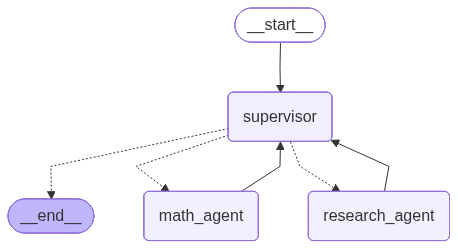

In [7]:
from IPython.display import display, Image

display(Image(supervisor.get_graph().draw_mermaid_png()))

The supervisor is aware of both our research and math agents, and knows which agent is responsible for which kind of work.

The prompt clearly instructs that the supervisor should assign one task at a time and to never do the work itself.

`add_handoff_back_messages` tracks message handoff, while `output_mode` ensures we can audit the entire chain of interactions for each request.

Let’s ask:

*Find US and New York state GDP in 2024. What % of US GDP was New York state?*

In [8]:
for chunk in supervisor.stream(
    {
        "messages": [
            {
                "role": "user",
                "content": "find US and New York state GDP in 2024. what % of US GDP was New York state?",
            }
        ]
    },
):
    pretty_print_messages(chunk)

final_message_history = chunk["supervisor"]["messages"]

Update from node supervisor:


================================ Human Message =================================

find US and New York state GDP in 2024. what % of US GDP was New York state?
================================== Ai Message ==================================
Name: supervisor
Tool Calls:
  transfer_to_research_agent (call_gxzw1gXGvHrJ0aRPIrIZfjsj)
 Call ID: call_gxzw1gXGvHrJ0aRPIrIZfjsj
  Args:
================================= Tool Message =================================
Name: transfer_to_research_agent

Successfully transferred to research_agent


Update from node research_agent:


================================ Human Message =================================

find US and New York state GDP in 2024. what % of US GDP was New York state?
================================== Ai Message ==================================
Name: supervisor
Tool Calls:
  transfer_to_research_agent (call_gxzw1gXGvHrJ0aRPIrIZfjsj)
 Call ID: call_gxzw1gXGvHrJ0aRPIrIZfjsj
  Args:
==================

1. Supervisor receives the user question
1. Transfer to Research Agent
1. Research Agent Returns Results
1. Supervisor Transfers to Math Agent
1. Math Agent Calculates Percentage
1. Supervisor Compiles the Final Answer

![](assets/img/14-supervisor-agents-02.gif)

We can also build this pattern from scratch.

We need to create the logic for agents to hand off control and their working context to each other.

This is done using “handoff tools”, which act as signals that the supervisor can call to pass control (and message history) to a worker agent.

First, we need a generic function to create handoff tools. Each tool is responsible for transferring the workflow to a specified agent and appending a record of the handoff to the message history.

In [9]:
from typing import Annotated
from langchain_core.tools import tool, InjectedToolCallId
from langgraph.prebuilt import InjectedState
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.types import Command

def create_handoff_tool(*, agent_name: str, description: str | None = None):
    name = f"transfer_to_{agent_name}"
    description = description or f"Ask {agent_name} for help."

    @tool(name, description=description)
    def handoff_tool(
        state: Annotated[MessagesState, InjectedState],
        tool_call_id: Annotated[str, InjectedToolCallId],
    ) -> Command:
        tool_message = {
            "role": "tool",
            "content": f"Successfully transferred to {agent_name}",
            "name": name,
            "tool_call_id": tool_call_id,
        }
        return Command(
            goto=agent_name,                              # 1. Where to go next (target agent)
            update={**state, "messages": state["messages"] + [tool_message]},  # 2. Update history
            graph=Command.PARENT,                         # 3. Work in parent graph context
        )

    return handoff_tool

* Each handoff tool, when called, adds a message to the history documenting the transfer and tells LangGraph which agent should receive control next.

* The `goto` parameter ensures the workflow moves directly to the intended agent.

* The `update` merges in the tool message so the receiving agent (or supervisor) gets the full story so far.

* The `graph=Command.PARENT` signals that this transition happens in the parent (supervisor’s) orchestration context.

Next, we create handoff tools for both the research agent and the math agent using the factory above:

In [10]:
# Handoffs
assign_to_research_agent = create_handoff_tool(
    agent_name="research_agent",
    description="Assign task to a researcher agent.",
)

assign_to_math_agent = create_handoff_tool(
    agent_name="math_agent",
    description="Assign task to a math agent.",
)

Next, let’s define the supervisor agent.

In [11]:
supervisor_agent = create_react_agent(
    model="openai:gpt-4.1",
    tools=[assign_to_research_agent, assign_to_math_agent],
    prompt=(
        "You are a supervisor managing two agents:\n"
        "- a research agent. Assign research-related tasks to this agent\n"
        "- a math agent. Assign math-related tasks to this agent\n"
        "Assign work to one agent at a time, do not call agents in parallel.\n"
        "Do not do any work yourself."
    ),
    name="supervisor",
)

/tmp/ipykernel_216648/2290245348.py:1: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  supervisor_agent = create_react_agent(


In [12]:
from langgraph.graph import StateGraph, END, START, MessagesState

# Define the multi-agent supervisor graph
supervisor_graph = (
    StateGraph(MessagesState)
    # Add the supervisor node, with possible destinations for visualization
    .add_node(supervisor_agent, destinations=("research_agent", "math_agent", END))
    # Add the research and math agent nodes
    .add_node(research_agent)
    .add_node(math_agent)
    # Start the flow at the supervisor
    .add_edge(START, "supervisor")
    # Agents always hand back control to the supervisor after their work
    .add_edge("research_agent", "supervisor")
    .add_edge("math_agent", "supervisor")
    .compile()
)

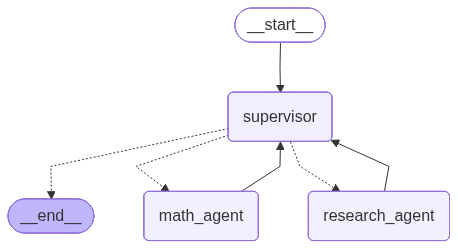

In [13]:
display(Image(supervisor_graph.get_graph().draw_mermaid_png()))

In [15]:
for chunk in supervisor.stream(
    {
        "messages": [
            {
                "role": "user",
                "content": rf"find US and New York state GDP in 2024. what % of US GDP was New York state?",
            }
        ]
    },
):
    pretty_print_messages(chunk)

final_message_history = chunk["supervisor"]["messages"]

Update from node supervisor:


================================ Human Message =================================

find US and New York state GDP in 2024. what % of US GDP was New York state?
================================== Ai Message ==================================
Name: supervisor
Tool Calls:
  transfer_to_research_agent (call_vuUbhbvFY4i0ME20nQSYsekJ)
 Call ID: call_vuUbhbvFY4i0ME20nQSYsekJ
  Args:
================================= Tool Message =================================
Name: transfer_to_research_agent

Successfully transferred to research_agent


Update from node research_agent:


================================ Human Message =================================

find US and New York state GDP in 2024. what % of US GDP was New York state?
================================== Ai Message ==================================
Name: supervisor
Tool Calls:
  transfer_to_research_agent (call_vuUbhbvFY4i0ME20nQSYsekJ)
 Call ID: call_vuUbhbvFY4i0ME20nQSYsekJ
  Args:
==================

As our multi agent system matures, we may want more precise and task-oriented delegation between agents. Instead of sending the entire message history and having each agent figure out what to do, the supervisor can explicitly formulate and deliver a clear, focused task for the next agent.

The main difference is in the handoff tool:

In [16]:
from langgraph.types import Send

def create_task_description_handoff_tool(
    *, agent_name: str, description: str | None = None
):
    name = f"transfer_to_{agent_name}"
    description = description or f"Ask {agent_name} for help."

    @tool(name, description=description)
    def handoff_tool(
        # This is filled by the supervisor LLM
        task_description: Annotated[
            str,
            "Description of what the next agent should do, including all of the relevant context.",
        ],
        # These parameters are ignored by the LLM
        state: Annotated[MessagesState, InjectedState],
    ) -> Command:
        task_description_message = {"role": "user", "content": task_description}
        agent_input = {**state, "messages": [task_description_message]}
        return Command(
            goto=[Send(agent_name, agent_input)],  # Send the crafted message to the agent
            graph=Command.PARENT,
        )

    return handoff_tool

The supervisor crafts a succinct `task_description` (e.g., “Retrieve the latest GDP figures for the US and New York State for 2024”).

This description is passed as a single user message to the selected agent.

In [17]:
assign_to_research_agent_with_description = create_task_description_handoff_tool(
    agent_name="research_agent",
    description="Assign task to a researcher agent.",
)

assign_to_math_agent_with_description = create_task_description_handoff_tool(
    agent_name="math_agent",
    description="Assign task to a math agent.",
)

Create a supervisor agent that uses these new tools:

In [18]:
supervisor_agent_with_description = create_react_agent(
    model="openai:gpt-4.1",
    tools=[
        assign_to_research_agent_with_description,
        assign_to_math_agent_with_description,
    ],
    prompt=(
        "You are a supervisor managing two agents:\n"
        "- a research agent. Assign research-related tasks to this assistant\n"
        "- a math agent. Assign math-related tasks to this assistant\n"
        "Assign work to one agent at a time, do not call agents in parallel.\n"
        "Do not do any work yourself."
    ),
    name="supervisor",
)

/tmp/ipykernel_216648/2647568899.py:1: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  supervisor_agent_with_description = create_react_agent(


Combine everything in a state graph:

In [19]:
from langgraph.graph import StateGraph, START, END, MessagesState

supervisor_with_description = (
    StateGraph(MessagesState)
    .add_node(
        supervisor_agent_with_description, destinations=("research_agent", "math_agent")
    )
    .add_node(research_agent)
    .add_node(math_agent)
    .add_edge(START, "supervisor")
    .add_edge("research_agent", "supervisor")
    .add_edge("math_agent", "supervisor")
    .compile()
)

Agents now receive only the explicit task from the supervisor, not the full message history.

Agents can be dumber (and faster), as they don’t need to parse context — they just do what they’re told in the task description.

Each agent’s “view” of the world is limited to the task at hand, improving security and modularity.

In [21]:
for chunk in supervisor_with_description.stream(
    {
        "messages": [
            {
                "role": "user",
                "content": rf"find US and New York state GDP in 2024. what % of US GDP was New York state?",
            }
        ]
    },
):
    pretty_print_messages(chunk)

final_message_history = chunk["supervisor"]["messages"]

Update from node supervisor:




Update from node research_agent:


================================ Human Message =================================

Find data for the 2024 GDP of the United States and New York State. Also, note if the 2024 numbers are projections or estimates if final numbers are not yet available.
================================== Ai Message ==================================
Name: research_agent
Tool Calls:
  tavily_search_results_json (call_kOxyP2LvXxgaF2E8A4nqGddV)
 Call ID: call_kOxyP2LvXxgaF2E8A4nqGddV
  Args:
    query: 2024 GDP of the United States
  tavily_search_results_json (call_cNmDxxsLzRh1qGSKLslJJGl1)
 Call ID: call_cNmDxxsLzRh1qGSKLslJJGl1
  Args:
    query: 2024 GDP of New York State
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "United States GDP - Trading Economics", "url": "https://tradingeconomics.com/united-states/gdp", "content": "##### Members\n\n##### \n\n# United